### This code provides supports for results on Regression Analyses of A, including those in Main Text section 2.3.

In [1]:
import statsmodels.api as sm
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import matplotlib.lines as mlines
from statsmodels.stats.multitest import multipletests


d:\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [2]:
###data source 1: census data
df_census_all=pd.read_csv('data/census/all_census_data_with_location.csv')
###data source 1: census data

df_census_all['census_block_group']=df_census_all['census_block_group'].astype(str)

In [3]:
#input
dict_state={'1': 'AL', '2': 'AK', '4': 'AZ', '5': 'AR', '6': 'CA', '8': 'CO', '9': 'CT', '10': 'DE', '11': 'DC', '12': 'FL',
            '13': 'GA', '15': 'HI', '16': 'ID','17': 'IL', '18': 'IN', '19': 'IA', '20': 'KS', '21': 'KY', '22': 'LA', '23': 'ME', 
            '24': 'MD', '25': 'MA', '26': 'MI', '27': 'MN', '28': 'MS', '29': 'MO','30': 'MT', '31': 'NE', '32': 'NV', '33': 'NH', 
            '34': 'NJ', '35': 'NM', '36': 'NY', '37': 'NC', '38': 'ND', '39': 'OH', '40': 'OK', '41': 'OR', '42': 'PA','44': 'RI', 
            '45': 'SC', '46': 'SD', '47': 'TN', '48': 'TX', '49': 'UT', '50': 'VT', '51': 'VA', '53': 'WA', '54': 'WV', '55': 'WI', 
            '56': 'WY', '60': 'AS', '66': 'GU', '69': 'MP', '72': 'PR', '74': 'UM', '78': 'VI'}

def class_sig(pv):
    if pv<0.001:
        return '***'
    elif pv<0.01:
        return '**'
    elif pv<0.05:
        return '*'
    else:
        return 'NS' 

country-wide regression

In [5]:
all_pvals = []
all_vars = []
all_models = []

df_c=[]
for key in ['Health Care Services','Grocery and Food Supply','Housing and Real Estate']:
    col=['census_block_group','ParentType','num_accessible_facility','demand_ratios','demand_met_in_local']
###data source 2: accratio data 5 mile   
    homoPath='data/A under 5-mile setting/'+key+'.csv'
    df_reg=pd.read_csv(homoPath,usecols=col)
###data source 2: accratio data 5 mile
    
    

    df_reg['census_block_group']=df_reg['census_block_group'].astype(str)

    df_reg=pd.merge(df_reg,df_census_all, how='left',on='census_block_group')

    df_reg['dum_age']=df_reg.apply(lambda x: 1 if x['percent_above_65']>0.5 else 0.5 ,axis=1)
    df_reg['dum_age']=df_reg.apply(lambda x: 0 if x['percent_above_65']<0.2 else x['dum_age'] ,axis=1)
    
    df_reg=df_reg[df_reg['dum_age']!=0.5]
    #homo
    df_reg=df_reg.dropna()
    df_c.append(df_reg)
    num_obs=len(df_reg)
    num_old_obs=len(df_reg[df_reg['dum_age']==1])
    
    df_reg['state']=df_reg['state'].astype(int)

    if (num_obs>0) &(num_old_obs>0):

        y=df_reg.loc[:,['demand_met_in_local']]

        
        if key =='Health Care Services':
            reg4_X=['dum_age','demand_ratios',
                       'median_income_normalized by 250000','percent_undergraduate or higher','percent_minority','Pct_E8_Hlth',
                         'E_PctLowWage', 'NatWalkInd', 'isUrban',
                        'state']
        elif key =='Grocery and Food Supply':
            reg4_X=['dum_age','demand_ratios',
                       'median_income_normalized by 250000','percent_undergraduate or higher','percent_minority',
                        'Pct_E8_Ret', 'E_PctLowWage', 'NatWalkInd', 'isUrban',
                        'state'] 
        else:
            reg4_X=['dum_age','demand_ratios',
                       'median_income_normalized by 250000','percent_undergraduate or higher','percent_minority',
                         'Pct_E8_Svc', 'E_PctLowWage', 'NatWalkInd', 'isUrban',
                        'state']             

                
        x4=df_reg.loc[:,reg4_X]
        x4=sm.add_constant(x4)
        model4=sm.OLS(y,x4).fit()   
        
        print(model4.summary())
        print(key)

        for var, pval in model4.pvalues.items():
            all_pvals.append(pval)
            all_vars.append(var)
            all_models.append(key)

# FDR correction
reject, pvals_corrected, _, _ = multipletests(all_pvals, alpha=0.05, method='fdr_bh')

results_df = pd.DataFrame({
    'Model': all_models,
    'Variable': all_vars,
    'Raw P': all_pvals,
    'Adjusted P (FDR)': pvals_corrected,
    'Significant (FDR)': reject
})


                             OLS Regression Results                            
Dep. Variable:     demand_met_in_local   R-squared:                       0.373
Model:                             OLS   Adj. R-squared:                  0.372
Method:                  Least Squares   F-statistic:                     9407.
Date:                 Mon, 02 Jun 2025   Prob (F-statistic):               0.00
Time:                         15:34:31   Log-Likelihood:                 18276.
No. Observations:               158459   AIC:                        -3.653e+04
Df Residuals:                   158448   BIC:                        -3.642e+04
Df Model:                           10                                         
Covariance Type:             nonrobust                                         
                                         coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------

In [27]:
df2=df_c[2][['census_block_group','demand_met_in_local','dum_age','demand_ratios',
                       'median_income_normalized by 250000','percent_undergraduate or higher','percent_minority','Pct_E8_Hlth','Pct_E8_Ret','Pct_E8_Svc',
                         'E_PctLowWage', 'NatWalkInd', 'isUrban',
                        'state']]
df2=df2.rename(columns={'demand_met_in_local':'A_HRE','dum_age':'is_HighAging_cbg','demand_ratios':'ratio_of_visits_to_population',
                        'median_income_normalized by 250000':'median_income_normalized_by_250000',
                        'percent_undergraduate or higher':'percent_undergraduate_or_higher',
                        'Pct_E8_Hlth':'land_use_HCS',
                        'Pct_E8_Ret':'land_use_GFS',
                        'Pct_E8_Svc':'land_use_HRE',
                        'E_PctLowWage':'pctLowWage'
                        })

In [26]:
df_c[0][['census_block_group','ParentType','demand_met_in_local']]

,census_block_group,ParentType,demand_met_in_local
2,10010202001,Health Care Services,0.655172
3,10010202002,Health Care Services,0.666667
4,10010203001,Health Care Services,0.292135
7,10010204002,Health Care Services,0.443966
10,10010205001,Health Care Services,0.433628
...,...,...,...
217730,560430003012,Health Care Services,0.822222
217731,560430003013,Health Care Services,0.600000
217734,560459511001,Health Care Services,0.000000
217736,560459513001,Health Care Services,0.428571


In [28]:
df1=df_c[1][['census_block_group','demand_met_in_local']].rename(columns={'demand_met_in_local':'A_GFS'})

In [29]:
df0=df_c[0][['census_block_group','demand_met_in_local']].rename(columns={'demand_met_in_local':'A_HCS'})

In [30]:
dfm=pd.merge(df2,df0,on='census_block_group',how='left')
dfm=pd.merge(dfm,df1,on='census_block_group',how='left')

In [ ]:
#dfm[['census_block_group', 'A_HRE', 'A_HCS', 'A_GFS', 'is_HighAging_cbg',
#       'ratio_of_visits_to_population', 'median_income_normalized_by_250000',
#       'percent_undergraduate_or_higher', 'percent_minority', 'land_use_HCS',
#       'land_use_GFS', 'land_use_HRE', 'pctLowWage', 'NatWalkInd', 'isUrban',
#       'state']].to_excel('SourceData_Table1.xlsx', sheet_name='Table1', index=False)

In [39]:
def format_p(p):
    return '<0.001' if p < 0.001 else f'{p:.3f}'
results_df['Raw P'] = results_df['Raw P'].apply(format_p)
results_df['Adjusted P (FDR)'] = results_df['Adjusted P (FDR)'].apply(format_p)

In [40]:
results_df

,Model,Variable,Raw P,Adjusted P (FDR),Significant (FDR)
0,Health Care Services,const,0.005,0.005,True
1,Health Care Services,dum_age,<0.001,<0.001,True
2,Health Care Services,demand_ratios,<0.001,<0.001,True
3,Health Care Services,median_income_normalized by 250000,<0.001,<0.001,True
4,Health Care Services,percent_undergraduate or higher,<0.001,<0.001,True
5,Health Care Services,percent_minority,0.492,0.492,False
6,Health Care Services,Pct_E8_Hlth,<0.001,<0.001,True
7,Health Care Services,E_PctLowWage,<0.001,<0.001,True
8,Health Care Services,NatWalkInd,<0.001,<0.001,True
9,Health Care Services,isUrban,<0.001,<0.001,True


state-wide regression

In [42]:
#input
dict_epsg={'1': '32616', '2': '32606', '4': '32612', '5': '32615', '6': '32611', '8': '32613', '9': '32618', '10': '32618', '11': '32618', '12': '32617', 
           '13': '32616', '15': '32604', '16': '32611', '17': '32616', '18': '32616', '19': '32615', '20': '32614', '21': '32616', '22': '32615', '23': '32619', 
           '24': '32618', '25': '32619', '26': '32617', '27': '32615', '28': '32616', '29': '32615', '30': '32612', '31': '32614', '32': '32611', '33': '32619', 
           '34': '32618', '35': '32613', '36': '32618', '37': '32617', '38': '32614', '39': '32617', '40': '32614', '41': '32610', '42': '32618', '44': '32619', 
           '45': '32617', '46': '32614', '47': '32616', '48': '32614', '49': '32612', '50': '32618', '51': '32618', '53': '32610', '54': '32617', '55': '32616', 
           '56': '32613', '72': '32619'}
dict_state={'1': 'AL', '2': 'AK', '4': 'AZ', '5': 'AR', '6': 'CA', '8': 'CO', '9': 'CT', '10': 'DE', '11': 'DC', '12': 'FL', '13': 'GA', '15': 'HI', '16': 'ID',
            '17': 'IL', '18': 'IN', '19': 'IA', '20': 'KS', '21': 'KY', '22': 'LA', '23': 'ME', '24': 'MD', '25': 'MA', '26': 'MI', '27': 'MN', '28': 'MS', '29': 'MO',
            '30': 'MT', '31': 'NE', '32': 'NV', '33': 'NH', '34': 'NJ', '35': 'NM', '36': 'NY', '37': 'NC', '38': 'ND', '39': 'OH', '40': 'OK', '41': 'OR', '42': 'PA', 
            '44': 'RI', '45': 'SC', '46': 'SD', '47': 'TN', '48': 'TX', '49': 'UT', '50': 'VT', '51': 'VA', '53': 'WA', '54': 'WV', '55': 'WI', '56': 'WY', '60': 'AS', 
            '66': 'GU', '69': 'MP', '72': 'PR', '74': 'UM', '78': 'VI'}

In [43]:
homoRegResult=[]



listHGH=['Health Care Services',
                 'Grocery and Food Supply',
                 'Housing and Real Estate']

for key in listHGH: 

###data source 2: accratio data 5 mile       
    homoPath='data/A under 5-mile setting/'+key+'.csv'
    col=['census_block_group','ParentType','num_accessible_facility','demand_ratios','demand_met_in_local']
    df_reg=pd.read_csv(homoPath,usecols=col)
###data source 2: accratio data 5 mile   


    df_reg['census_block_group']=df_reg['census_block_group'].astype(str)

    df_reg=pd.merge(df_reg,df_census_all, how='left',on='census_block_group')

    df_reg['dum_age']=df_reg.apply(lambda x: 1 if x['percent_above_65']>0.5 else 0.5 ,axis=1)
    df_reg['dum_age']=df_reg.apply(lambda x: 0 if x['percent_above_65']<0.2 else x['dum_age'] ,axis=1)
    
    df_reg=df_reg[df_reg['dum_age']!=0.5]
    #homo
    df_reg=df_reg.dropna()


    
    print('read data_'+key)
    
    for fip in dict_epsg.keys():
        state=dict_state[fip]
        print(len(df_reg[df_reg['state']==int(fip)]),state)
        #homo
        df_reg_state=df_reg[(df_reg['state']==int(fip))&(df_reg['dum_age']!=0.5)]

        num_obs=len(df_reg_state)
        
        num_old_obs=sum(df_reg_state['dum_age'])
        if (num_obs>0) &(num_old_obs>0):

            y=df_reg_state.loc[:,['demand_met_in_local']]

            if key =='Health Care Services':
                regx3=['dum_age','demand_ratios',
                        'median_income_normalized by 250000','percent_undergraduate or higher','percent_minority','Pct_E8_Hlth',
                            'E_PctLowWage', 'NatWalkInd', 'isUrban']
            elif key =='Grocery and Food Supply':
                regx3=['dum_age','demand_ratios',
                        'median_income_normalized by 250000','percent_undergraduate or higher','percent_minority',
                            'Pct_E8_Ret', 'E_PctLowWage', 'NatWalkInd', 'isUrban'] 
            else:
                regx3=['dum_age','demand_ratios',
                        'median_income_normalized by 250000','percent_undergraduate or higher','percent_minority',
                            'Pct_E8_Svc', 'E_PctLowWage', 'NatWalkInd', 'isUrban']    

            x3=df_reg_state.loc[:,regx3]
            x3=sm.add_constant(x3)
            
            model3=sm.OLS(y,x3).fit()

            homoRegResult.append((key,state,num_obs,num_old_obs,
                               model3.params[1],class_sig(model3.pvalues[1]),
                                 model3.conf_int()[0][1],model3.conf_int()[1][1]
                                 ))

        
        print(state+'_'+key+'_homo done')
        

dfHomoRegResultPa=pd.DataFrame(homoRegResult,columns=['ParentType','state','num_obs','num_old_obs',
                                                                                   'coeff_regC_4_ctrls','signif_regC',
                                                     'coeff_lowci','coeff_upperci']) 



read data_Health Care Services
2357 AL
AL_Health Care Services_homo done
445 AK
AK_Health Care Services_homo done
3091 AZ
AZ_Health Care Services_homo done
1455 AR
AR_Health Care Services_homo done
18206 CA
CA_Health Care Services_homo done
2738 CO
CO_Health Care Services_homo done
1846 CT
CT_Health Care Services_homo done
372 DE
DE_Health Care Services_homo done
366 DC
DC_Health Care Services_homo done
7493 FL
FL_Health Care Services_homo done
4331 GA
GA_Health Care Services_homo done
533 HI
HI_Health Care Services_homo done
683 ID
ID_Health Care Services_homo done
7260 IL
IL_Health Care Services_homo done
3605 IN
IN_Health Care Services_homo done
1794 IA
IA_Health Care Services_homo done
1695 KS
KS_Health Care Services_homo done
2407 KY
KY_Health Care Services_homo done
2531 LA
LA_Health Care Services_homo done
621 ME
ME_Health Care Services_homo done
2955 MD
MD_Health Care Services_homo done
3577 MA
MA_Health Care Services_homo done
5741 MI
MI_Health Care Services_homo done
3032 MN


C:\Users\Linao\AppData\Local\Temp\ipykernel_33948\3768005585.py:65: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  model3.params[1],class_sig(model3.pvalues[1]),
C:\Users\Linao\AppData\Local\Temp\ipykernel_33948\3768005585.py:65: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  model3.params[1],class_sig(model3.pvalues[1]),
C:\Users\Linao\AppData\Local\Temp\ipykernel_33948\3768005585.py:66: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  

NM_Health Care Services_homo done
11045 NY
NY_Health Care Services_homo done
4321 NC
NC_Health Care Services_homo done
389 ND
ND_Health Care Services_homo done
6476 OH
OH_Health Care Services_homo done
2232 OK
OK_Health Care Services_homo done
1768 OR
OR_Health Care Services_homo done
6548 PA
PA_Health Care Services_homo done
552 RI
RI_Health Care Services_homo done
2092 SC
SC_Health Care Services_homo done
431 SD
SD_Health Care Services_homo done
2911 TN
TN_Health Care Services_homo done
12399 TX
TX_Health Care Services_homo done
1488 UT
UT_Health Care Services_homo done
336 VT
VT_Health Care Services_homo done
3856 VA
VA_Health Care Services_homo done
3610 WA
WA_Health Care Services_homo done
936 WV
WV_Health Care Services_homo done
3337 WI
WI_Health Care Services_homo done
303 WY
WY_Health Care Services_homo done
0 PR
PR_Health Care Services_homo done
read data_Grocery and Food Supply
2354 AL
AL_Grocery and Food Supply_homo done
440 AK
AK_Grocery and Food Supply_homo done
3092 AZ
AZ

C:\Users\Linao\AppData\Local\Temp\ipykernel_33948\3768005585.py:65: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  model3.params[1],class_sig(model3.pvalues[1]),
C:\Users\Linao\AppData\Local\Temp\ipykernel_33948\3768005585.py:65: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  model3.params[1],class_sig(model3.pvalues[1]),
C:\Users\Linao\AppData\Local\Temp\ipykernel_33948\3768005585.py:66: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  

NM_Grocery and Food Supply_homo done
11067 NY
NY_Grocery and Food Supply_homo done
4323 NC
NC_Grocery and Food Supply_homo done
388 ND
ND_Grocery and Food Supply_homo done
6482 OH
OH_Grocery and Food Supply_homo done
2230 OK
OK_Grocery and Food Supply_homo done
1768 OR
OR_Grocery and Food Supply_homo done
6546 PA
PA_Grocery and Food Supply_homo done
550 RI
RI_Grocery and Food Supply_homo done
2093 SC
SC_Grocery and Food Supply_homo done
429 SD
SD_Grocery and Food Supply_homo done
2911 TN
TN_Grocery and Food Supply_homo done
12397 TX
TX_Grocery and Food Supply_homo done
1487 UT
UT_Grocery and Food Supply_homo done
339 VT
VT_Grocery and Food Supply_homo done
3860 VA
VA_Grocery and Food Supply_homo done
3614 WA
WA_Grocery and Food Supply_homo done
932 WV
WV_Grocery and Food Supply_homo done
3339 WI
WI_Grocery and Food Supply_homo done
306 WY
WY_Grocery and Food Supply_homo done
0 PR
PR_Grocery and Food Supply_homo done
read data_Housing and Real Estate
2357 AL
AL_Housing and Real Estate_h

C:\Users\Linao\AppData\Local\Temp\ipykernel_33948\3768005585.py:65: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  model3.params[1],class_sig(model3.pvalues[1]),
C:\Users\Linao\AppData\Local\Temp\ipykernel_33948\3768005585.py:65: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  model3.params[1],class_sig(model3.pvalues[1]),
C:\Users\Linao\AppData\Local\Temp\ipykernel_33948\3768005585.py:66: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  

ND_Housing and Real Estate_homo done
6491 OH
OH_Housing and Real Estate_homo done
2231 OK
OK_Housing and Real Estate_homo done
1763 OR
OR_Housing and Real Estate_homo done
6553 PA
PA_Housing and Real Estate_homo done
552 RI
RI_Housing and Real Estate_homo done
2093 SC
SC_Housing and Real Estate_homo done
428 SD
SD_Housing and Real Estate_homo done
2909 TN
TN_Housing and Real Estate_homo done
12399 TX
TX_Housing and Real Estate_homo done
1489 UT
UT_Housing and Real Estate_homo done
338 VT
VT_Housing and Real Estate_homo done
3863 VA
VA_Housing and Real Estate_homo done
3616 WA
WA_Housing and Real Estate_homo done
938 WV
WV_Housing and Real Estate_homo done
3335 WI
WI_Housing and Real Estate_homo done
306 WY
WY_Housing and Real Estate_homo done
0 PR
PR_Housing and Real Estate_homo done


C:\Users\Linao\AppData\Local\Temp\ipykernel_33948\3768005585.py:65: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  model3.params[1],class_sig(model3.pvalues[1]),
C:\Users\Linao\AppData\Local\Temp\ipykernel_33948\3768005585.py:65: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  model3.params[1],class_sig(model3.pvalues[1]),
C:\Users\Linao\AppData\Local\Temp\ipykernel_33948\3768005585.py:66: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  

In [ ]:
#dfHomoRegResultPa[dfHomoRegResultPa['num_old_obs']>=30][['ParentType','state','num_obs','num_old_obs','coeff_regC_4_ctrls','coeff_lowci','coeff_upperci']].rename(
#                            columns={
#                                    'ParentType':'service_type','num_obs':'number_of_CBG','num_old_obs':'number_of_HighAging_CBG',
#                                    'coeff_regC_4_ctrls':'mean_coeff','coeff_lowci':'lower95%CI','coeff_upperci':'upper95%CI'
#                            }).to_excel('SourceData_Fig4.xlsx', sheet_name='Fig4a-c', index=False)

In [19]:
key='Health Care Services' #Grocery and Food Supply  Housing and Real Estate
df=dfHomoRegResultPa[(dfHomoRegResultPa['num_old_obs']>=30)][['ParentType','state','num_obs']]

dff=pd.DataFrame()
dff['state']=list(df['state'].unique())
dff['HCS number of observation']=dff['state'].apply(lambda x: df[(df['state']==x)&(df['ParentType']=='Health Care Services')]['num_obs'].iat[0] if len(df[(df['state']==x)&(df['ParentType']=='Health Care Services')])!=0 else 'NA')
dff['GFS number of observation']=dff['state'].apply(lambda x: df[(df['state']==x)&(df['ParentType']=='Grocery and Food Supply')]['num_obs'].iat[0] if len(df[(df['state']==x)&(df['ParentType']=='Grocery and Food Supply')])!=0 else 'NA')
dff['HRE number of observation']=dff['state'].apply(lambda x: df[(df['state']==x)&(df['ParentType']=='Housing and Real Estate')]['num_obs'].iat[0] if len(df[(df['state']==x)&(df['ParentType']=='Housing and Real Estate')])!=0 else 'NA')

In [20]:
dff

,state,HCS number of observation,GFS number of observation,HRE number of observation
0,AZ,3091,3092,3102
1,CA,18206,18220,18242
2,FL,7493,7496,7496
3,IL,7260,7266,7263
4,MD,2955,2953,2956
5,MA,3577,3583,3586
6,MI,5741,5749,NA
7,NV,1383,1383,1387
8,NJ,4887,4891,4896
9,NY,11045,11067,11050


In [ ]:
#dfHomoRegResultPa.to_csv(r'..\..\..\R1\new results\regression\state_HGH_regression_data.csv')

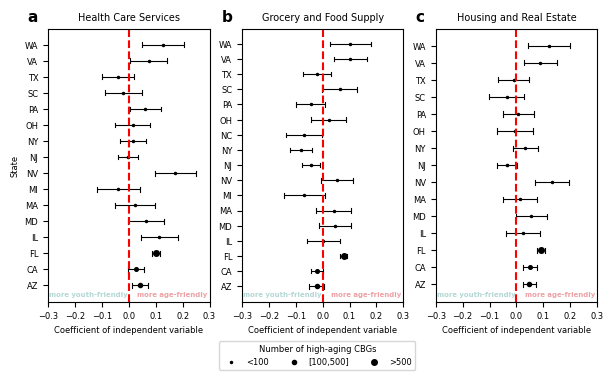

In [71]:
#visualization
width_in_inches = 180 * 0.0393701
height_in_inches =width_in_inches/2
lowOldNum=30
fig,ax=plt.subplots(1,3,figsize=(width_in_inches,height_in_inches))

colors={'less than or equal to 0.5':'#B3D8D5','greater than 0.5': '#EDA1A4'}

listHGH=['Health Care Services',
                 'Grocery and Food Supply',
                 'Housing and Real Estate']
s0=0.15
smid=0.3
s1=0.4

for k,key in enumerate(listHGH): 
    df=dfHomoRegResultPa[(dfHomoRegResultPa['num_old_obs']>=lowOldNum)&(dfHomoRegResultPa['ParentType']==key)]

    states=list(df['state'])
    means=list(df['coeff_regC_4_ctrls'])
    lowers=list(df['coeff_lowci'])
    uppers=list(df['coeff_upperci'])


    p0=np.log( 100 )
    p1=np.log( 500 )
    

    
    # 绘制点
    for i in range(len(means)):
        
        noc=df[df['state']==states[i]]['num_old_obs'].iat[0]
        if noc<100:
            size=s0
        elif noc<500:

            p=np.log(df[df['state']==states[i]]['num_old_obs'].iat[0])
            size=s0+(p-p0)*(s1-s0)/(p1-p0)
        else:
            size=s1

        ax[k].plot(means[i], i, marker='o', color='black', markersize=size*10,linestyle='None')
    # 绘制水平线
    for i in range(len(means)):
        ax[k].hlines(i, lowers[i], uppers[i], colors='black',linewidth=0.8 ,linestyles='-')
        ax[k].plot([lowers[i],lowers[i]],[i-0.15,i+0.15],linewidth=0.8,color='black')
        ax[k].plot([uppers[i],uppers[i]],[i-0.15,i+0.15],linewidth=0.8,color='black')
    # 添加垂直线
    ax[k].axvline(x=0, color='red', linestyle='--')
    # 设置轴标签和标题
    ax[k].set_xlabel('Coefficient of independent variable',fontsize=6)
    if k<1:
        ax[k].set_ylabel('State',fontsize=6)
        
    else:
        ax[k].set_ylabel('')
        

    ax[k].text(0.03,-0.7,'more age-friendly',fontsize=5,color=colors['greater than 0.5'], fontweight='bold')#'
    ax[k].text(-0.295,-0.7,'more youth-friendly',fontsize=5,color=colors['less than or equal to 0.5'], fontweight='bold')#'
        
    ax[k].set_title(key,fontsize=7)
    # 调整轴范围
    ax[k].set_xlim([-0.3, 0.3])
    ax[k].set_ylim([-1, len(means)])
    # 添加研究标签
    ax[k].set_yticks(range(len(means)))
    ax[k].set_yticklabels(states,fontsize=6)

    ax[k].tick_params(axis='both', which='both', bottom=True, left=True, labelsize=6)  # 设置x y轴标签大小
# 显示图形  

labels = ['a', 'b', 'c']
for i in range(3):
    # 使用 ax[i].text() 在左上角添加标签
    ax[i].text(-0.125, 1.07, labels[i], transform=ax[i].transAxes, 
               fontsize=11, fontweight='bold', va='top', ha='left')



circle4 = mlines.Line2D([], [], color='black', marker='o', linestyle='None', markersize=10*s0, label='<100')
circle5 = mlines.Line2D([], [], color='black', marker='o', linestyle='None', markersize=10*smid, label='[100,500]')
circle6= mlines.Line2D([], [], color='black', marker='o', linestyle='None', markersize=10*s1, label='>500')
# 添加图例并指定自定义图例元素
plt.legend(handles=[circle4, circle5, circle6], 
           ncol=3, 
           bbox_to_anchor=(-0.1, -0.13), 
           title='Number of high-aging CBGs', 
           frameon=True, 
           fontsize=6,  # 图例项文字大小
           title_fontsize=6)  # 图例标题文字大小

plt.show()

In [ ]:
#fig.savefig(r'..\..\..\R1\new results\regression\state_HGH_regression_numoldcbg30.pdf', dpi=300, bbox_inches='tight', format='pdf')